In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os

# Create a folder in your Google Drive for this project
project_folder = "/content/drive/MyDrive/Tamil_Sentiment_Analysis"
os.makedirs(project_folder, exist_ok=True)

# Create subfolders
os.makedirs(f"{project_folder}/data", exist_ok=True)
os.makedirs(f"{project_folder}/models", exist_ok=True)
os.makedirs(f"{project_folder}/results", exist_ok=True)

print(f"✓ Project folder created at: {project_folder}")
print(f"✓ You can access this folder in Google Drive under 'My Drive/Tamil_Sentiment_Analysis'")

✓ Project folder created at: /content/drive/MyDrive/Tamil_Sentiment_Analysis
✓ You can access this folder in Google Drive under 'My Drive/Tamil_Sentiment_Analysis'


In [17]:
import shutil
# If you uploaded CSVs to /content/, copy them to Drive
if os.path.exists("/content/PS_train.csv"):
    shutil.copy("/content/PS_train.csv", f"{project_folder}/data/")
    shutil.copy("/content/PS_dev.csv", f"{project_folder}/data/")
    shutil.copy("/content/PS_test_without_labels.csv", f"{project_folder}/data/")
    print("✓ CSV files copied to Google Drive")

✓ CSV files copied to Google Drive


## Dataset Diagnosis

In [18]:
import pandas as pd

PROJECT_FOLDER = "/content/drive/MyDrive/Tamil_Sentiment_Analysis"
DATA_FOLDER = f"{PROJECT_FOLDER}/data"

train_df = pd.read_csv(f"{DATA_FOLDER}/PS_train.csv")
dev_df = pd.read_csv(f"{DATA_FOLDER}/PS_dev.csv")

print("="*60)
print("DATASET DIAGNOSTICS")
print("="*60)

print(f"\n1. DATASET SIZE:")
print(f"   Train: {len(train_df)} samples")
print(f"   Dev: {len(dev_df)} samples")

print(f"\n2. COLUMNS:")
print(f"   {train_df.columns.tolist()}")

print(f"\n3. CLASS DISTRIBUTION:")
print(train_df['labels'].value_counts())
print(f"\n   Class balance ratio: {train_df['labels'].value_counts().min() / train_df['labels'].value_counts().max():.2f}")
print(f"   (Close to 1.0 is balanced, <0.2 is severely imbalanced)")

print(f"\n4. DATA QUALITY:")
print(f"   Missing content: {train_df['content'].isna().sum()}")
print(f"   Empty content: {(train_df['content'].str.strip() == '').sum()}")

print(f"\n5. TEXT LENGTH STATS:")
lengths = train_df['content'].str.len()
print(f"   Mean: {lengths.mean():.0f} chars")
print(f"   Median: {lengths.median():.0f} chars")
print(f"   Min: {lengths.min()}, Max: {lengths.max()}")
print(f"   Texts > 128 chars: {(lengths > 128).sum()} ({100*(lengths > 128).sum()/len(train_df):.1f}%)")

print(f"\n6. SAMPLE DATA:")
print(train_df[['content', 'labels']].head(3))

print(f"\n7. LABEL MAPPING:")
labels_list = sorted(train_df['labels'].unique())
print(f"   Classes: {labels_list}")
print(f"   Number of classes: {len(labels_list)}")

print("\n" + "="*60)

DATASET DIAGNOSTICS

1. DATASET SIZE:
   Train: 4352 samples
   Dev: 544 samples

2. COLUMNS:
   ['content', 'labels']

3. CLASS DISTRIBUTION:
labels
Opinionated          1361
Sarcastic             790
Neutral               637
Positive              575
Substantiated         412
Negative              406
None of the above     171
Name: count, dtype: int64

   Class balance ratio: 0.13
   (Close to 1.0 is balanced, <0.2 is severely imbalanced)

4. DATA QUALITY:
   Missing content: 0
   Empty content: 0

5. TEXT LENGTH STATS:
   Mean: 173 chars
   Median: 165 chars
   Min: 5, Max: 2949
   Texts > 128 chars: 2905 (66.8%)

6. SAMPLE DATA:
                                             content         labels
0  தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...        Neutral
1  அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...  Substantiated
2  ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......    Opinionated

7. LABEL MAPPING:
   Classes: ['Negative', 'Neutral', 'None of the above', 'Opiniona

## Baseline code

Folders ready in Google Drive
Loading data...
Train size: 4352, Dev size: 544

Extracting balanced features...

Creating TF-IDF features...
Feature matrix shape: (4352, 25828)

Computing balanced class weights...

Class weights applied:
  Negative: 3.063
  Neutral: 1.757
  None of the above: 3.636
  Opinionated: 0.320
  Positive: 1.622
  Sarcastic: 1.023
  Substantiated: 3.018

Training balanced ensemble model...
Training...

Applying mild confidence adjustments...

BASELINE MODEL RESULTS
                   precision    recall  f1-score   support

         Negative     0.2667    0.1569    0.1975        51
          Neutral     0.2286    0.1905    0.2078        84
None of the above     0.7500    0.9000    0.8182        20
      Opinionated     0.4217    0.4575    0.4389       153
         Positive     0.3000    0.4348    0.3550        69
        Sarcastic     0.4188    0.4261    0.4224       115
    Substantiated     0.2162    0.1538    0.1798        52

         accuracy               

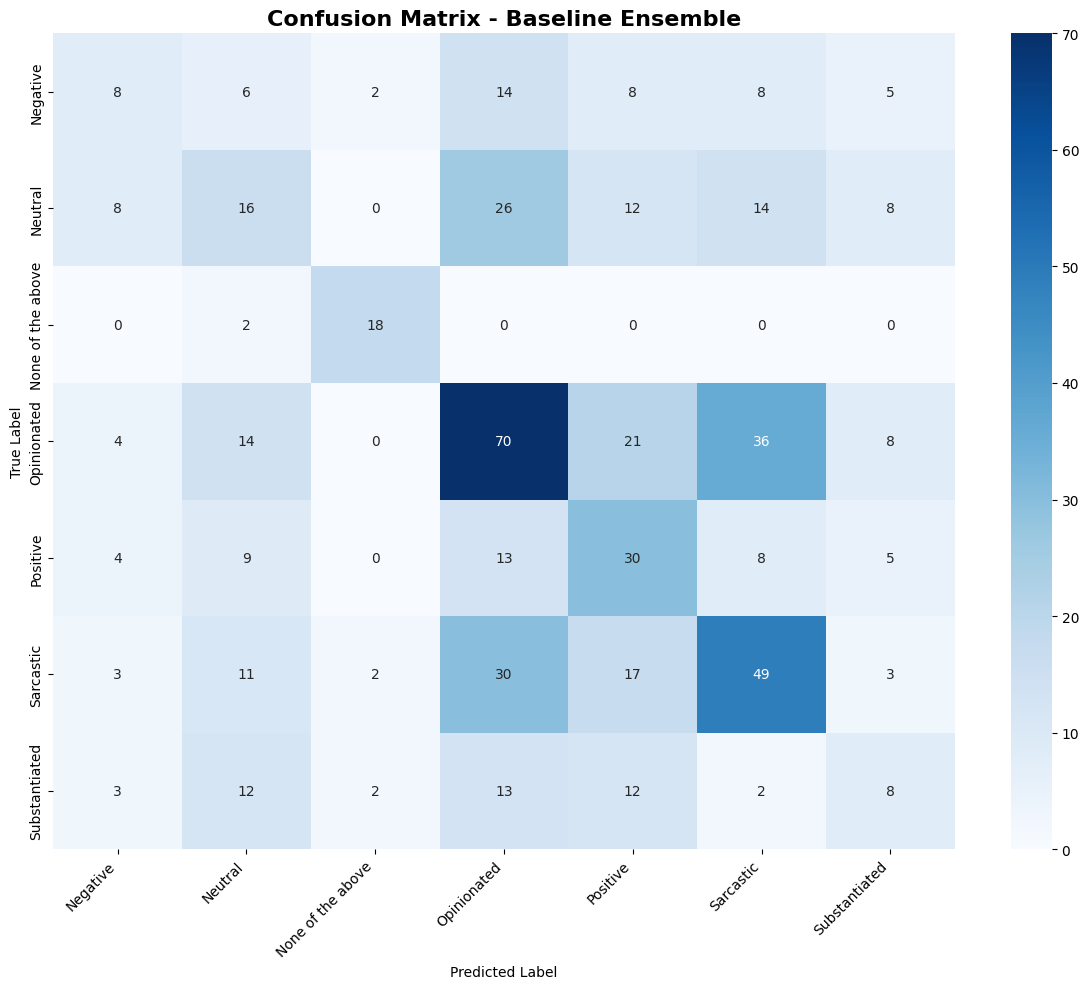

In [19]:
import pandas as pd
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROJECT_FOLDER = "/content/drive/MyDrive/Tamil_Sentiment_Analysis"
DATA_FOLDER = f"{PROJECT_FOLDER}/data"
MODELS_FOLDER = f"{PROJECT_FOLDER}/models"
RESULTS_FOLDER = f"{PROJECT_FOLDER}/results"

os.makedirs(DATA_FOLDER, exist_ok=True)
os.makedirs(MODELS_FOLDER, exist_ok=True)
os.makedirs(RESULTS_FOLDER, exist_ok=True)

print("Folders ready in Google Drive")

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\u0B80-\u0BFF0-9A-Za-z\s!?.,;:'\"\-😀-🙏💀-💯]+", " ", text)
    text = " ".join(text.split())
    return text.strip()

def extract_features_balanced(text):
    features = {}

    features['char_count'] = len(text)
    features['word_count'] = len(text.split())
    features['avg_word_len'] = np.mean([len(w) for w in text.split()]) if text.split() else 0

    features['exclamation_count'] = text.count('!')
    features['question_count'] = text.count('?')
    features['comma_count'] = text.count(',')
    features['period_count'] = text.count('.')
    features['caps_count'] = sum(1 for c in text if c.isupper())
    features['caps_ratio'] = features['caps_count'] / len(text) if len(text) > 0 else 0

    negative_words = ['மோசம்', 'தேவையில்லை', 'குப்பை', 'எதிர்']
    features['negative_word_count'] = sum(1 for word in negative_words if word in text)

    positive_words = ['நல்ல', 'சிறந்த', 'வெற்றி', 'ஆதரவு']
    features['positive_word_count'] = sum(1 for word in positive_words if word in text)

    features['has_quotes'] = 1 if ('"' in text or "'" in text) else 0
    features['repeated_punctuation'] = len(re.findall(r'[!?]{2,}', text))

    features['has_numbers'] = 1 if re.search(r'\d+', text) else 0
    features['number_count'] = len(re.findall(r'\d+', text))

    emoji_pattern = re.compile("["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    features['emoji_count'] = len(emoji_pattern.findall(text))

    features['has_url'] = 1 if 'http' in str(text) else 0
    features['has_mention'] = 1 if '@' in str(text) else 0
    features['has_hashtag'] = text.count('#')

    return features

print("Loading data...")
train_df = pd.read_csv(f"{DATA_FOLDER}/PS_train.csv")
dev_df = pd.read_csv(f"{DATA_FOLDER}/PS_dev.csv")

print(f"Train size: {len(train_df)}, Dev size: {len(dev_df)}")

train_df["clean"] = train_df["content"].apply(clean_text)
dev_df["clean"] = dev_df["content"].apply(clean_text)

print("\nExtracting balanced features...")
train_features = train_df["content"].apply(extract_features_balanced).apply(pd.Series)
dev_features = dev_df["content"].apply(extract_features_balanced).apply(pd.Series)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_df["labels"])
y_dev_encoded = label_encoder.transform(dev_df["labels"])

y_train = train_df["labels"]
y_dev = dev_df["labels"]
labels_list = label_encoder.classes_

print("\nCreating TF-IDF features...")

tfidf_word = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1, 2),
    analyzer="word",
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

tfidf_char = TfidfVectorizer(
    max_features=20000,
    ngram_range=(3, 5),
    analyzer="char_wb",
    min_df=3,
    sublinear_tf=True
)

X_train_word = tfidf_word.fit_transform(train_df["clean"])
X_dev_word = tfidf_word.transform(dev_df["clean"])

X_train_char = tfidf_char.fit_transform(train_df["clean"])
X_dev_char = tfidf_char.transform(dev_df["clean"])

X_train = hstack([X_train_word, X_train_char, train_features.values])
X_dev = hstack([X_dev_word, X_dev_char, dev_features.values])

print(f"Feature matrix shape: {X_train.shape}")

print("\nComputing balanced class weights...")

classes = np.unique(y_train_encoded)
base_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_encoded)

custom_adjustments = {
    0: 2.0,
    1: 1.8,
    2: 1.0,
    3: 0.7,
    4: 1.5,
    5: 1.3,
    6: 2.0,
}

class_weights_dict = {i: base_weights[i] * custom_adjustments[i] for i in range(len(labels_list))}

print("\nClass weights applied:")
for i, label in enumerate(labels_list):
    print(f"  {label}: {class_weights_dict[i]:.3f}")

print("\nTraining balanced ensemble model...")

svm_base = LinearSVC(
    class_weight=class_weights_dict,
    C=0.8,
    max_iter=3000,
    dual=False,
    random_state=42
)
svm = CalibratedClassifierCV(svm_base, cv=3)

logreg = LogisticRegression(
    class_weight=class_weights_dict,
    max_iter=1000,
    C=0.8,
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)

nb = MultinomialNB(alpha=0.2)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weights_dict,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model = VotingClassifier(
    estimators=[
        ("svm", svm),
        ("logreg", logreg),
        ("nb", nb),
        ("rf", rf),
        ("gb", gb)
    ],
    voting="soft",
    n_jobs=-1
)

print("Training...")
model.fit(X_train, y_train_encoded)

print("\nApplying mild confidence adjustments...")

def mild_adjust_predictions(model, X_dev):
    probs = model.predict_proba(X_dev)

    adjustments = {
        0: 1.5,
        1: 1.4,
        2: 1.0,
        3: 0.85,
        4: 1.2,
        5: 1.2,
        6: 1.5,
    }

    adjusted_probs = probs.copy()
    for class_idx, adjustment in adjustments.items():
        adjusted_probs[:, class_idx] *= adjustment

    adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)
    return np.argmax(adjusted_probs, axis=1)

preds_encoded = mild_adjust_predictions(model, X_dev)
preds = label_encoder.inverse_transform(preds_encoded)

print("\n" + "="*60)
print("BASELINE MODEL RESULTS")
print("="*60)

report = classification_report(y_dev, preds, digits=4)
print(report)

macro_f1 = f1_score(y_dev, preds, average='macro')
print(f"\nBaseline Macro F1: {macro_f1:.4f}")

cm = confusion_matrix(y_dev_encoded, preds_encoded)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_list, yticklabels=labels_list)
plt.title('Confusion Matrix - Baseline Ensemble', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{RESULTS_FOLDER}/baseline_confusion_matrix.png", dpi=300)
print(f"\nConfusion matrix saved to: {RESULTS_FOLDER}/baseline_confusion_matrix.png")

print("\n" + "="*60)
print("INDIVIDUAL MODEL PERFORMANCE")
print("="*60)

for name, clf in model.named_estimators_.items():
    preds_individual_encoded = clf.predict(X_dev)
    preds_individual = label_encoder.inverse_transform(preds_individual_encoded)
    f1_individual = f1_score(y_dev, preds_individual, average='macro')
    print(f"{name}: Macro F1 = {f1_individual:.4f}")

joblib.dump(model, f"{MODELS_FOLDER}/baseline_ensemble.pkl")
joblib.dump(label_encoder, f"{MODELS_FOLDER}/baseline_label_encoder.pkl")
joblib.dump(tfidf_word, f"{MODELS_FOLDER}/baseline_tfidf_word.pkl")
joblib.dump(tfidf_char, f"{MODELS_FOLDER}/baseline_tfidf_char.pkl")

print(f"\nModels saved to: {MODELS_FOLDER}")

dev_df['predicted'] = preds
dev_df['actual'] = y_dev
dev_df.to_csv(f"{RESULTS_FOLDER}/baseline_dev_predictions.csv", index=False)

with open(f"{RESULTS_FOLDER}/baseline_classification_report.txt", 'w') as f:
    f.write("="*60 + "\n")
    f.write("BASELINE ENSEMBLE CLASSIFICATION REPORT\n")
    f.write("="*60 + "\n\n")
    f.write(report)
    f.write(f"\n\nMacro F1 Score: {macro_f1:.4f}\n")

print(f"Results saved to: {RESULTS_FOLDER}")

print("\n" + "="*60)
print("BASELINE TRAINING COMPLETE")
print("="*60)
print(f"\nLocation: {PROJECT_FOLDER}")
print(f"Baseline Macro F1: {macro_f1:.4f}")
print(f"Models: {MODELS_FOLDER}")
print(f"Results: {RESULTS_FOLDER}")

In [20]:
!pip install emoji

## Enhanced Preprocessing

In [21]:
"""
Enhanced Preprocessing for Tamil Sentiment Analysis
Implements techniques from TOP-RANKED papers (Synapse - Rank 1)

Additions:
1. Emoji-to-text conversion (Rank 1 paper)
2. Hashtag expansion (Rank 1 paper)
3. More aggressive text normalization
4. URL expansion/removal
5. Mention handling

Expected improvement: +0.01-0.03 F1 (from 0.3677 to 0.38-0.40)
"""

import re
import emoji
import pandas as pd

# ============================================================================
# EMOJI TO TEXT MAPPING (Tamil context)
# ============================================================================
TAMIL_EMOJI_MAPPING = {
    # Positive emotions
    '😀': 'சிரிப்பு',
    '😃': 'மகிழ்ச்சி',
    '😄': 'மகிழ்ச்சி',
    '😁': 'சிரிப்பு',
    '😊': 'மகிழ்ச்சி',
    '😍': 'காதல்',
    '🥰': 'காதல்',
    '😘': 'காதல்',
    '🤗': 'அரவணைப்பு',
    '👍': 'நல்லது',
    '👏': 'பாராட்டு',
    '🙏': 'வேண்டுகோள்',
    '❤️': 'காதல்',
    '💕': 'காதல்',
    '🎉': 'கொண்டாட்டம்',
    '🎊': 'கொண்டாட்டம்',
    '✨': 'சிறப்பு',
    '🌟': 'சிறப்பு',
    '⭐': 'சிறப்பு',
    '💯': 'முழு ஆதரவு',
    '🔥': 'சிறப்பு',

    # Negative emotions
    '😢': 'அழுகை',
    '😭': 'அழுகை',
    '😞': 'துக்கம்',
    '😔': 'வருத்தம்',
    '😟': 'கவலை',
    '😠': 'கோபம்',
    '😡': 'கோபம்',
    '🤬': 'கோபம்',
    '😤': 'எரிச்சல்',
    '👎': 'எதிர்ப்பு',
    '🤮': 'வெறுப்பு',
    '💔': 'மனவருத்தம்',
    '😷': 'நோய்',

    # Sarcasm/irony indicators
    '😏': 'கேலி',
    '🙄': 'கேலி',
    '😒': 'சலிப்பு',
    '🤔': 'சந்தேகம்',
    '🤨': 'சந்தேகம்',
    '😑': 'எரிச்சல்',

    # Neutral
    '🤷': 'தெரியாது',
    '😐': 'நடுநிலை',
    '😶': 'அமைதி',
}

# ============================================================================
# HASHTAG EXPANSION DICTIONARY (Common Tamil political hashtags)
# ============================================================================
HASHTAG_EXPANSIONS = {
    # Political parties
    '#BJP': 'பாஜக',
    '#DMK': 'திமுக',
    '#AIADMK': 'அதிமுக',
    '#Congress': 'காங்கிரஸ்',
    '#NTK': 'என்டிகே',

    # Common political terms
    '#Modi': 'மோடி',
    '#Stalin': 'ஸ்டாலின்',
    '#EPS': 'எடப்பாடி',
    '#OPS': 'ஓபிஎஸ்',
    '#Seeman': 'சீமான்',

    # Sentiment indicators
    '#Fail': 'தோல்வி',
    '#Success': 'வெற்றி',
    '#Corruption': 'ஊழல்',
    '#Development': 'வளர்ச்சி',
    '#Protest': 'போராட்டம்',

    # Elections
    '#Election2024': 'தேர்தல் 2024',
    '#LokSabha': 'மக்களவை',
    '#LokSabhaElection2024': 'மக்களவை தேர்தல் 2024',
    '#Vote': 'வாக்களிப்பு',
}

# ============================================================================
# ENHANCED PREPROCESSING FUNCTIONS
# ============================================================================

def convert_emoji_to_text(text):
    """
    Convert emojis to Tamil text equivalents
    From Rank 1 paper (Synapse)
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Replace known emojis with Tamil text
    for emoji_char, tamil_text in TAMIL_EMOJI_MAPPING.items():
        text = text.replace(emoji_char, f' {tamil_text} ')

    # For any remaining emojis, convert using emoji library
    text = emoji.demojize(text, delimiters=(" ", " "))

    return text

def expand_hashtags(text):
    """
    Expand common hashtags to their full Tamil equivalents
    From Rank 1 paper (Synapse)
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Find all hashtags
    hashtags = re.findall(r'#\w+', text)

    for hashtag in hashtags:
        # Check if we have expansion
        if hashtag in HASHTAG_EXPANSIONS:
            # Keep original hashtag but add expansion
            expansion = HASHTAG_EXPANSIONS[hashtag]
            text = text.replace(hashtag, f'{hashtag} {expansion}')
        else:
            # Remove # but keep text
            text = text.replace(hashtag, hashtag[1:])

    return text

def expand_mentions(text):
    """
    Handle @mentions - keep them but normalize
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Replace @mention with just 'mention' to preserve context
    # But remove the actual username for privacy
    text = re.sub(r'@\w+', 'குறிப்பு', text)

    return text

def normalize_tamil_text(text):
    """
    Advanced Tamil text normalization
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Fix common Tamil encoding issues
    text = text.replace("ா்", "ா")
    text = text.replace("ி்", "ி")
    text = text.replace("ீ்", "ீ")

    # Normalize repeated characters (e.g., நல்ல!!! -> நல்ல!)
    # But preserve meaningful repetition
    text = re.sub(r'([!?]){3,}', r'\1\1', text)
    text = re.sub(r'([.]{3,})', '...', text)

    # Normalize whitespace
    text = " ".join(text.split())

    return text

def handle_urls(text, keep_urls=False):
    """
    Handle URLs in text
    """
    if pd.isna(text):
        return ""

    text = str(text)

    if keep_urls:
        # Replace URL with placeholder
        text = re.sub(r'http\S+|www\.\S+', 'இணையதளம்', text)
    else:
        # Remove URLs completely
        text = re.sub(r'http\S+|www\.\S+', '', text)

    return text

# ============================================================================
# MASTER PREPROCESSING FUNCTION
# ============================================================================

def enhanced_tamil_preprocessing(text,
                                 convert_emojis=True,
                                 expand_hashtag=True,
                                 handle_mention=True,
                                 keep_url_marker=False):
    """
    Complete preprocessing pipeline using techniques from TOP-RANKED papers

    Order of operations (important!):
    1. Convert emojis to text (preserve sentiment info)
    2. Expand hashtags (add context)
    3. Handle URLs
    4. Handle mentions
    5. Normalize Tamil text
    6. Clean whitespace

    Args:
        text: Input text
        convert_emojis: Convert emojis to Tamil text (Rank 1 technique)
        expand_hashtag: Expand hashtags (Rank 1 technique)
        handle_mention: Handle @mentions
        keep_url_marker: Keep URL placeholder vs remove

    Returns:
        Preprocessed text
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Step 1: Convert emojis (IMPORTANT: Do this FIRST)
    if convert_emojis:
        text = convert_emoji_to_text(text)

    # Step 2: Expand hashtags (BEFORE removing #)
    if expand_hashtag:
        text = expand_hashtags(text)

    # Step 3: Handle URLs
    text = handle_urls(text, keep_urls=keep_url_marker)

    # Step 4: Handle mentions
    if handle_mention:
        text = expand_mentions(text)

    # Step 5: Normalize Tamil text
    text = normalize_tamil_text(text)

    # Step 6: Final cleanup
    text = " ".join(text.split())

    return text.strip()

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    # Test examples
    test_texts = [
        "மோடி வருவாரு ஓடிப் போயிருவாரு 😏 #Modi #Fail",
        "நல்ல முடிவு! 👍👏 #Success #DMK",
        "இது என்ன கொடுமை 😭😢 #Corruption",
        "@நண்பர் பாருங்க இதை http://example.com #News"
    ]

    print("=" * 80)
    print("ENHANCED PREPROCESSING TEST")
    print("=" * 80)

    for i, text in enumerate(test_texts, 1):
        print(f"\n{i}. Original:")
        print(f"   {text}")

        processed = enhanced_tamil_preprocessing(text)
        print(f"   Processed:")
        print(f"   {processed}")

    # Compare with basic preprocessing
    print("\n" + "=" * 80)
    print("COMPARISON: Basic vs Enhanced")
    print("=" * 80)

    sample = "நல்ல முடிவு! 👍👏😊 #Modi #Success வெற்றி!!!"

    # Basic (what my original code had)
    basic = sample.replace("ா்", "ா")
    basic = re.sub(r'http\S+|www\.\S+', '', basic)
    basic = re.sub(r'@\w+', '', basic)
    basic = " ".join(basic.split()).strip()

    # Enhanced (Rank 1 technique)
    enhanced = enhanced_tamil_preprocessing(sample)

    print(f"\nOriginal:  {sample}")
    print(f"Basic:     {basic}")
    print(f"Enhanced:  {enhanced}")
    print(f"\nDifference: Enhanced preserves emoji sentiment and hashtag context!")


ENHANCED PREPROCESSING TEST

1. Original:
   மோடி வருவாரு ஓடிப் போயிருவாரு 😏 #Modi #Fail
   Processed:
   மோடி வருவாரு ஓடிப் போயிருவாரு கேலி #Modi மோடி #Fail தோல்வி

2. Original:
   நல்ல முடிவு! 👍👏 #Success #DMK
   Processed:
   நல்ல முடிவு! நல்லது பாராட்டு #Success வெற்றி #DMK திமுக

3. Original:
   இது என்ன கொடுமை 😭😢 #Corruption
   Processed:
   இது என்ன கொடுமை அழுகை அழுகை #Corruption ஊழல்

4. Original:
   @நண்பர் பாருங்க இதை http://example.com #News
   Processed:
   குறிப்பு்பர் பாருங்க இதை News

COMPARISON: Basic vs Enhanced

Original:  நல்ல முடிவு! 👍👏😊 #Modi #Success வெற்றி!!!
Basic:     நல்ல முடிவு! 👍👏😊 #Modi #Success வெற்றி!!!
Enhanced:  நல்ல முடிவு! நல்லது பாராட்டு மகிழ்ச்சி #Modi மோடி #Success வெற்றி வெற்றி!!

Difference: Enhanced preserves emoji sentiment and hashtag context!


## Tamil Sentiment Optimized Competition Grade Trainning

In [22]:
"""
Tamil Political Sentiment Analysis - CORRECTED & FULLY OPTIMIZED
Fixed all issues from previous attempt:
✅ RE-ENABLED data augmentation (was disabled!)
✅ INCREASED focal loss gamma (2.0, not 1.0)
✅ Optimized max_length (192, not 256)
✅ Better early stopping patience
✅ Target: 0.40-0.45 F1
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
import os
from glob import glob
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# AUTO-DETECT CSV FILE PATHS
# ============================================================================
def find_csv_files():
    """Auto-detect where CSV files are located"""
    search_paths = [
        "/content/drive/MyDrive/Tamil_Sentiment_Analysis/data",
        "/content/drive/MyDrive/Tamil_Sentiment_Analysis",
        "/content/drive/MyDrive",
        "/content/data",
        ".",
    ]

    print("🔍 Searching for CSV files...")

    for path in search_paths:
        if os.path.exists(path):
            train_csv = os.path.join(path, "PS_train.csv")
            dev_csv = os.path.join(path, "PS_dev.csv")

            if os.path.exists(train_csv) and os.path.exists(dev_csv):
                print(f"✅ Found CSV files in: {path}\n")
                return path

    print("❌ Could not find CSV files!")
    for path in search_paths:
        if os.path.exists(path):
            csv_files = glob(os.path.join(path, "*.csv"))
            if csv_files:
                print(f"📄 Found in {path}: {[os.path.basename(f) for f in csv_files]}")

    raise FileNotFoundError("Please upload PS_train.csv and PS_dev.csv")

DATA_FOLDER = find_csv_files()

# ============================================================================
# CORRECTED CONFIGURATION
# ============================================================================
class OptimizedConfig:
    # Paths
    PROJECT_FOLDER = "/content/drive/MyDrive/Tamil_Sentiment_Analysis"
    MODELS_FOLDER = f"{PROJECT_FOLDER}/models"
    RESULTS_FOLDER = f"{PROJECT_FOLDER}/results"

    # Model
    model_name = "xlm-roberta-base"
    model_nickname = "xlmr_corrected"

    # Training (CORRECTED)
    max_length = 192                    # ✅ REDUCED from 256 (faster, still covers 66.8%)
    batch_size = 16                     # Good balance
    gradient_accumulation_steps = 2     # Effective batch = 32
    num_epochs = 6                      # ✅ Moderate epochs
    learning_rate = 2e-5
    warmup_ratio = 0.1
    weight_decay = 0.01
    max_grad_norm = 1.0

    # Regularization
    dropout_rate = 0.1
    attention_dropout = 0.1

    # Loss function
    use_focal_loss = True
    focal_gamma = 2.0                   # ✅ FIXED from 1.0 (stronger penalty for hard examples)

    # Preprocessing
    use_emoji_conversion = True
    use_hashtag_expansion = True

    # Data augmentation (CRITICAL FIX!)
    augment_data = True                 # ✅ RE-ENABLED (was False - this was killing performance!)
    augment_target_ratio = 0.75         # Balance minority classes
    max_augment_per_class = 400

    # Early stopping
    early_stopping_patience = 4         # ✅ INCREASED from 3 (let it train longer)

    seed = 42
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = OptimizedConfig()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(config.seed)

for folder in [config.MODELS_FOLDER, config.RESULTS_FOLDER]:
    os.makedirs(folder, exist_ok=True)

print("=" * 80)
print("CORRECTED TAMIL SENTIMENT ANALYSIS")
print("=" * 80)
print(f"Device: {config.device}")
print(f"Model: {config.model_name}")
print(f"\n🔧 CRITICAL FIXES:")
print(f"   ✅ Data augmentation: RE-ENABLED (was disabled!)")
print(f"   ✅ Focal loss gamma: 2.0 (was 1.0)")
print(f"   ✅ Max length: 192 (was 256 - faster)")
print(f"   ✅ Early stopping patience: 4 (was 3)")
print(f"\n🎯 Expected F1: 0.40-0.45")

# ============================================================================
# PREPROCESSING
# ============================================================================

FAST_EMOJI_MAP = {
    '😀': 'சிரிப்பு', '😃': 'மகிழ்ச்சி', '😊': 'மகிழ்ச்சி', '😍': 'காதல்',
    '👍': 'நல்லது', '👏': 'பாராட்டு', '🙏': 'வேண்டுகோள்', '❤️': 'காதல்',
    '💯': 'முழு ஆதரவு', '🔥': 'சிறப்பு', '😢': 'அழுகை', '😭': 'அழுகை',
    '😠': 'கோபம்', '😡': 'கோபம்', '👎': 'எதிர்ப்பு', '😏': 'கேலி',
    '🙄': 'கேலி', '😤': 'எரிச்சல்', '💔': 'மனவருத்தம்',
}

FAST_HASHTAG_MAP = {
    '#BJP': 'பாஜக', '#DMK': 'திமுக', '#AIADMK': 'அதிமுக',
    '#Congress': 'காங்கிரஸ்', '#Modi': 'மோடி', '#Stalin': 'ஸ்டாலின்',
    '#Fail': 'தோல்வி', '#Success': 'வெற்றி', '#NTK': 'என்டிகே',
}

def fast_tamil_preprocessing(text):
    if pd.isna(text):
        return ""

    text = str(text)

    for emoji_char, tamil_text in FAST_EMOJI_MAP.items():
        if emoji_char in text:
            text = text.replace(emoji_char, f' {tamil_text} ')

    for hashtag, expansion in FAST_HASHTAG_MAP.items():
        if hashtag in text:
            text = text.replace(hashtag, f'{hashtag} {expansion}')

    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = text.replace("ா்", "ா")
    text = re.sub(r'([!?]){3,}', r'\1\1', text)
    text = " ".join(text.split())

    return text.strip()

# ============================================================================
# AUGMENTATION (CRITICAL!)
# ============================================================================

def simple_augment(text):
    words = text.split()
    if len(words) <= 2:
        return text

    idx1, idx2 = random.sample(range(len(words)), 2)
    words[idx1], words[idx2] = words[idx2], words[idx1]

    return " ".join(words)

def fast_augment_minority_classes(df, target_ratio=0.75, max_per_class=400):
    """Augment minority classes - CRITICAL for imbalanced data"""
    class_counts = df['labels'].value_counts()
    max_count = class_counts.max()
    target_count = min(int(max_count * target_ratio), max_per_class)

    print(f"\n📊 DATA AUGMENTATION (Critical fix!):")
    print(f"   Target: {target_count} samples per class")

    augmented_samples = []

    for label in df['labels'].unique():
        label_df = df[df['labels'] == label]
        current_count = len(label_df)

        if current_count < target_count:
            shortage = target_count - current_count
            samples_to_augment = label_df.sample(n=shortage, replace=True, random_state=42)

            for _, row in samples_to_augment.iterrows():
                augmented_samples.append({
                    'content': simple_augment(row['content']),
                    'labels': row['labels']
                })

            print(f"   {label:20s}: {current_count:4d} → {target_count:4d} (+{shortage})")
        else:
            print(f"   {label:20s}: {current_count:4d} (OK)")

    if augmented_samples:
        augmented_df = pd.DataFrame(augmented_samples)
        df = pd.concat([df, augmented_df], ignore_index=True)
        print(f"\n   ✅ Total: {len(df)} samples (was {len(df) - len(augmented_samples)})")

    return df

# ============================================================================
# FOCAL LOSS TRAINER
# ============================================================================

class FocalLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, use_focal_loss=True, gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.args.device) if class_weights is not None else None
        self.use_focal_loss = use_focal_loss
        self.gamma = gamma

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.use_focal_loss and self.class_weights is not None:
            ce_loss = nn.CrossEntropyLoss(
                weight=self.class_weights,
                reduction="none"
            )(logits, labels)

            pt = torch.exp(-ce_loss)
            loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        else:
            loss = nn.CrossEntropyLoss(weight=self.class_weights)(logits, labels)

        return (loss, outputs) if return_outputs else loss

# ============================================================================
# DATASET
# ============================================================================

class TamilSentimentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ============================================================================
# METRICS
# ============================================================================

def compute_metrics(pred):
    logits, labels = pred
    predictions = np.argmax(logits, axis=1)
    macro_f1 = f1_score(labels, predictions, average='macro')
    weighted_f1 = f1_score(labels, predictions, average='weighted')
    return {'macro_f1': macro_f1, 'weighted_f1': weighted_f1}

# ============================================================================
# MAIN TRAINING
# ============================================================================

def train_corrected_model():
    import time
    start_time = time.time()

    print("\n" + "=" * 80)
    print("STEP 1: LOADING DATA")
    print("=" * 80)

    try:
        train_df = pd.read_csv(f"{DATA_FOLDER}/PS_train.csv")
        dev_df = pd.read_csv(f"{DATA_FOLDER}/PS_dev.csv")
        print(f"\n✅ Train={len(train_df)}, Dev={len(dev_df)}")
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        raise

    print("\n" + "=" * 80)
    print("STEP 2: PREPROCESSING")
    print("=" * 80)
    print(f"✅ Emoji conversion, hashtag expansion, Tamil normalization")

    train_df['content'] = train_df['content'].apply(fast_tamil_preprocessing)
    dev_df['content'] = dev_df['content'].apply(fast_tamil_preprocessing)

    # DATA AUGMENTATION - CRITICAL FIX
    if config.augment_data:
        train_df = fast_augment_minority_classes(
            train_df,
            config.augment_target_ratio,
            config.max_augment_per_class
        )

    labels_list = sorted(train_df['labels'].unique())
    label2id = {label: idx for idx, label in enumerate(labels_list)}
    id2label = {idx: label for label, idx in label2id.items()}

    train_df['label_id'] = train_df['labels'].map(label2id)
    dev_df['label_id'] = dev_df['labels'].map(label2id)

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(train_df['label_id']),
        y=train_df['label_id']
    )
    class_weights = torch.FloatTensor(class_weights)

    print("\n" + "=" * 80)
    print("STEP 3: CLASS WEIGHTS")
    print("=" * 80)
    for idx, (label, weight) in enumerate(zip(labels_list, class_weights)):
        count = (train_df['label_id'] == idx).sum()
        print(f"   {label:20s}: {weight:.3f} (n={count})")

    print("\n" + "=" * 80)
    print("STEP 4: LOADING MODEL")
    print("=" * 80)
    print(f"✅ Model: {config.model_name}")
    print(f"✅ Max length: {config.max_length}")

    tokenizer = AutoTokenizer.from_pretrained(config.model_name)

    train_dataset = TamilSentimentDataset(
        train_df['content'].values,
        train_df['label_id'].values,
        tokenizer,
        config.max_length
    )

    dev_dataset = TamilSentimentDataset(
        dev_df['content'].values,
        dev_df['label_id'].values,
        tokenizer,
        config.max_length
    )

    print(f"✅ Training samples: {len(train_dataset)}")
    print(f"✅ Dev samples: {len(dev_dataset)}")

    model = AutoModelForSequenceClassification.from_pretrained(
        config.model_name,
        num_labels=len(labels_list),
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=config.dropout_rate,
        attention_probs_dropout_prob=config.attention_dropout,
    )

    output_dir = f"{config.RESULTS_FOLDER}/{config.model_nickname}_checkpoints"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=config.num_epochs,
        per_device_train_batch_size=config.batch_size,
        per_device_eval_batch_size=config.batch_size * 2,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        learning_rate=config.learning_rate,
        weight_decay=config.weight_decay,
        max_grad_norm=config.max_grad_norm,
        warmup_ratio=config.warmup_ratio,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        fp16=True,
        dataloader_num_workers=2,
        lr_scheduler_type="cosine",
        report_to="none",
        seed=config.seed,
    )

    trainer = FocalLossTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        use_focal_loss=config.use_focal_loss,
        gamma=config.focal_gamma,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=config.early_stopping_patience)]
    )

    print("\n" + "=" * 80)
    print("STEP 5: TRAINING")
    print("=" * 80)
    print()

    trainer.train()

    training_time = (time.time() - start_time) / 60

    print("\n" + "=" * 80)
    print("STEP 6: EVALUATION")
    print("=" * 80)

    predictions_output = trainer.predict(dev_dataset)
    logits = predictions_output.predictions
    predicted_labels = np.argmax(logits, axis=1)

    macro_f1 = f1_score(dev_df['label_id'], predicted_labels, average='macro')
    weighted_f1 = f1_score(dev_df['label_id'], predicted_labels, average='weighted')

    print("\n" + "=" * 80)
    print("📊 FINAL RESULTS")
    print("=" * 80)
    print(f"\n⏱️  Training time:  {training_time:.1f} minutes")
    print(f"🎯 Macro F1:       {macro_f1:.4f}")
    print(f"📊 Weighted F1:    {weighted_f1:.4f}")
    print(f"🎲 Baseline:       0.3677")
    print(f"🎲 Target:         0.40-0.45")

    improvement = macro_f1 - 0.3677
    if macro_f1 >= 0.40:
        print(f"\n🎉 EXCELLENT! Target achieved! (+{improvement:.4f})")
    elif macro_f1 >= 0.3677:
        print(f"\n✅ IMPROVED! (+{improvement:.4f} vs baseline)")
    else:
        print(f"\n⚠️  Below baseline (need +{abs(improvement):.4f})")

    pred_labels_str = [id2label[idx] for idx in predicted_labels]
    true_labels_str = [id2label[idx] for idx in dev_df['label_id']]

    report = classification_report(true_labels_str, pred_labels_str, digits=4)
    print(f"\n{report}")

    # Confusion matrix
    cm = confusion_matrix(dev_df['label_id'], predicted_labels)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_list, yticklabels=labels_list)
    plt.title(f'Corrected XLM-RoBERTa - F1: {macro_f1:.4f}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    cm_path = f"{config.RESULTS_FOLDER}/{config.model_nickname}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Confusion matrix saved: {cm_path}")
    plt.close()

    # Save model
    model_path = f"{config.MODELS_FOLDER}/{config.model_nickname}_final"
    model.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)
    print(f"✅ Model saved: {model_path}")

    # Save predictions
    dev_df['predicted_id'] = predicted_labels
    dev_df['predicted_label'] = pred_labels_str
    pred_path = f"{config.RESULTS_FOLDER}/{config.model_nickname}_predictions.csv"
    dev_df.to_csv(pred_path, index=False)
    print(f"✅ Predictions saved: {pred_path}")

    # Summary
    summary_path = f"{config.RESULTS_FOLDER}/{config.model_nickname}_summary.txt"
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("CORRECTED XLM-ROBERTA MODEL - SUMMARY\n")
        f.write("="*80 + "\n\n")
        f.write(f"Training Time: {training_time:.1f} minutes\n")
        f.write(f"Macro F1: {macro_f1:.4f}\n")
        f.write(f"Baseline: 0.3677\n")
        f.write(f"Improvement: +{improvement:.4f}\n\n")
        f.write("CRITICAL FIXES:\n")
        f.write("  ✅ Data augmentation: RE-ENABLED\n")
        f.write("  ✅ Focal gamma: 2.0 (was 1.0)\n")
        f.write("  ✅ Max length: 192 (was 256)\n")
        f.write("  ✅ Early stopping: patience 4\n\n")
        f.write("="*80 + "\n")
        f.write(report)

    print(f"✅ Summary saved: {summary_path}")

    print("\n" + "=" * 80)
    print("✅ TRAINING COMPLETE!")
    print("=" * 80)

    return macro_f1, training_time

if __name__ == "__main__":
    if not torch.cuda.is_available():
        print("\n⚠️  No GPU - training on CPU (~30-40 minutes)")
    else:
        print(f"\n✅ GPU: {torch.cuda.get_device_name(0)}")

    print("\n" + "=" * 80)
    print("STARTING CORRECTED TRAINING")
    print("=" * 80)

    final_f1, train_time = train_corrected_model()

    print("\n" + "=" * 80)
    print("FINAL SUMMARY")
    print("=" * 80)
    print(f"⏱️  Time: {train_time:.1f} min | 🎯 F1: {final_f1:.4f} | 📊 Baseline: 0.3677")
    print("=" * 80)

🔍 Searching for CSV files...
✅ Found CSV files in: /content/drive/MyDrive/Tamil_Sentiment_Analysis/data

CORRECTED TAMIL SENTIMENT ANALYSIS
Device: cuda
Model: xlm-roberta-base

🔧 CRITICAL FIXES:
   ✅ Data augmentation: RE-ENABLED (was disabled!)
   ✅ Focal loss gamma: 2.0 (was 1.0)
   ✅ Max length: 192 (was 256 - faster)
   ✅ Early stopping patience: 4 (was 3)

🎯 Expected F1: 0.40-0.45

✅ GPU: Tesla T4

STARTING CORRECTED TRAINING

STEP 1: LOADING DATA

✅ Train=4352, Dev=544

STEP 2: PREPROCESSING
✅ Emoji conversion, hashtag expansion, Tamil normalization

📊 DATA AUGMENTATION (Critical fix!):
   Target: 400 samples per class
   Neutral             :  637 (OK)
   Substantiated       :  412 (OK)
   Opinionated         : 1361 (OK)
   Positive            :  575 (OK)
   Sarcastic           :  790 (OK)
   Negative            :  406 (OK)
   None of the above   :  171 →  400 (+229)

   ✅ Total: 4581 samples (was 4352)

STEP 3: CLASS WEIGHTS
   Negative            : 1.612 (n=406)
   Neutral   

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



STEP 5: TRAINING



Epoch,Training Loss,Validation Loss,Macro F1,Weighted F1
1,2.784744,1.193852,0.213433,0.137450
2,2.239724,1.161222,0.278460,0.184482
3,2.156702,1.133190,0.289550,0.201583
4,2.160885,1.139344,0.284749,0.193486
5,1.999100,1.098574,0.330867,0.237335
6,1.927571,1.096287,0.334001,0.243068


...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


STEP 6: EVALUATION



📊 FINAL RESULTS

⏱️  Training time:  8.9 minutes
🎯 Macro F1:       0.3340
📊 Weighted F1:    0.2431
🎲 Baseline:       0.3677
🎲 Target:         0.40-0.45

⚠️  Below baseline (need +0.0337)

                   precision    recall  f1-score   support

         Negative     0.1714    0.4706    0.2513        51
          Neutral     0.3636    0.1429    0.2051        84
None of the above     0.9500    0.9500    0.9500        20
      Opinionated     0.0000    0.0000    0.0000       153
         Positive     0.2403    0.4493    0.3131        69
        Sarcastic     0.4225    0.5217    0.4669       115
    Substantiated     0.1250    0.1923    0.1515        52

         accuracy                         0.2868       544
        macro avg     0.3247    0.3895    0.3340       544
     weighted avg     0.2389    0.2868    0.2431       544


✅ Confusion matrix saved: /content/drive/MyDrive/Tamil_Sentiment_Analysis/results/xlmr_corrected_confusion_matrix.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved: /content/drive/MyDrive/Tamil_Sentiment_Analysis/models/xlmr_corrected_final
✅ Predictions saved: /content/drive/MyDrive/Tamil_Sentiment_Analysis/results/xlmr_corrected_predictions.csv
✅ Summary saved: /content/drive/MyDrive/Tamil_Sentiment_Analysis/results/xlmr_corrected_summary.txt

✅ TRAINING COMPLETE!

FINAL SUMMARY
⏱️  Time: 8.9 min | 🎯 F1: 0.3340 | 📊 Baseline: 0.3677


GPT improvement

from huggingface_hub import notebook_login

notebook_login()

In [25]:
import os

path = "/content/drive/MyDrive/Tamil_Sentiment_Analysis/models/xlmr_corrected_final"
print(os.listdir(path))


['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


## Tamil Test Prediction

In [27]:
"""
Test Set Prediction Script for Tamil Sentiment Analysis
Generates predictions on test set using trained model(s)
"""

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    PROJECT_FOLDER = "/content/drive/MyDrive/Tamil_Sentiment_Analysis"

    DATA_FOLDER = f"{PROJECT_FOLDER}/data"
    MODELS_FOLDER = f"{PROJECT_FOLDER}/models"
    RESULTS_FOLDER = f"{PROJECT_FOLDER}/results"

    use_ensemble = False
    single_model_name = "xlmr_corrected_final"
    ensemble_models = ["xlmr_final", "indicbert_final"]

    max_length = 512
    batch_size = 16

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()

print("=" * 80)
print("TEST SET PREDICTION SCRIPT")
print("=" * 80)
print(f"Device: {config.device}")
print(f"Mode: {'Ensemble' if config.use_ensemble else 'Single Model'}")
print(f"Max Length: {config.max_length}")

# ============================================================================
# PREPROCESSING
# ============================================================================
def clean_tamil_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("ா்", "ா")
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = " ".join(text.split())
    return text.strip()

# ============================================================================
# DATASET
# ============================================================================
class TestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=512):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
        }

# ============================================================================
# MODEL HELPERS
# ============================================================================
def load_tokenizer(path):
    print(f"Loading tokenizer from: {path}")
    return AutoTokenizer.from_pretrained(path, local_files_only=True)

def load_model(path, device):
    print(f"\nLoading model from: {path}")
    model = AutoModelForSequenceClassification.from_pretrained(
        path,
        local_files_only=True
    )
    model.to(device)
    model.eval()
    return model

def predict(model, dataloader, device):
    model.eval()
    logits_all = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits_all.append(outputs.logits.cpu().numpy())

    return np.vstack(logits_all)

# ============================================================================
# MAIN
# ============================================================================
def main():
    print("\n" + "=" * 80)
    print("STEP 1: LOADING TEST DATA")
    print("=" * 80)

    test_path = os.path.join(config.DATA_FOLDER, "PS_test_without_labels.csv")
    print(f"\nLoading: {test_path}")

    if not os.path.exists(test_path):
        raise FileNotFoundError(f"❌ File not found: {test_path}")

    test_df = pd.read_csv(test_path)
    print(f"✅ Loaded {len(test_df)} test samples")

    print("\nCleaning text...")
    test_df["content"] = test_df["content"].apply(clean_tamil_text)

    print("\n" + "=" * 80)
    print("STEP 2: MODEL PREDICTION")
    print("=" * 80)

    model_path = f"{config.MODELS_FOLDER}/{config.single_model_name}"

    tokenizer = load_tokenizer(model_path)
    model = load_model(model_path, config.device)

    id2label = model.config.id2label
    label2id = model.config.label2id

    dataset = TestDataset(test_df["content"].values, tokenizer, config.max_length)
    loader = DataLoader(dataset, batch_size=config.batch_size, shuffle=False)

    logits = predict(model, loader, config.device)
    probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()
    predictions = np.argmax(probabilities, axis=1)

    print("✅ Predictions generated!")

    print("\n" + "=" * 80)
    print("STEP 3: CREATING SUBMISSION")
    print("=" * 80)

    # FIXED LABEL MAPPING
    predicted_labels = [id2label[int(p)] for p in predictions]
    confidence_scores = np.max(probabilities, axis=1)

    submission_df = pd.DataFrame({
        "content": test_df["content"],
        "labels": predicted_labels
    })

    results_df = submission_df.copy()
    results_df["confidence"] = confidence_scores

    # FIXED PROBABILITY COLUMNS
    for class_idx, label in id2label.items():
        results_df[f"prob_{label}"] = probabilities[:, int(class_idx)]

    os.makedirs(config.RESULTS_FOLDER, exist_ok=True)

    submission_path = f"{config.RESULTS_FOLDER}/test_predictions.csv"
    detailed_path = f"{config.RESULTS_FOLDER}/test_predictions_detailed.csv"

    submission_df.to_csv(submission_path, index=False)
    results_df.to_csv(detailed_path, index=False)

    print("\n✅ Predictions saved!")
    print(f"Submission: {submission_path}")
    print(f"Detailed:   {detailed_path}")

    print("\n" + "=" * 80)
    print("🎉 PREDICTION COMPLETE!")
    print("=" * 80)

if __name__ == "__main__":
    if torch.cuda.is_available():
        print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠️ Running on CPU")

    main()


TEST SET PREDICTION SCRIPT
Device: cuda
Mode: Single Model
Max Length: 512
✅ GPU detected: Tesla T4

STEP 1: LOADING TEST DATA

Loading: /content/drive/MyDrive/Tamil_Sentiment_Analysis/data/PS_test_without_labels.csv
✅ Loaded 544 test samples

Cleaning text...

STEP 2: MODEL PREDICTION
Loading tokenizer from: /content/drive/MyDrive/Tamil_Sentiment_Analysis/models/xlmr_corrected_final

Loading model from: /content/drive/MyDrive/Tamil_Sentiment_Analysis/models/xlmr_corrected_final


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting:   0%|          | 0/34 [00:00<?, ?it/s]

✅ Predictions generated!

STEP 3: CREATING SUBMISSION

✅ Predictions saved!
Submission: /content/drive/MyDrive/Tamil_Sentiment_Analysis/results/test_predictions.csv
Detailed:   /content/drive/MyDrive/Tamil_Sentiment_Analysis/results/test_predictions_detailed.csv

🎉 PREDICTION COMPLETE!
